<a href="https://colab.research.google.com/github/tamaki-gth/cartpole_project/blob/main/2link_ipynb_%E3%81%AE%E3%82%B3%E3%83%94%E3%83%BC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np

m1=1.96
m2=1.68
#m2=8.78
l1=0.32
l2=0.44
lf=0.25
lh=0.19
mf=1.12
mh=0.42
mo=0.14
#mo=7.24
g=9.8
J1=0.017
J2=0.15
trq1=2
trq2=2
p1=0.16
p2=0.21
C1=0.05
C2=0.01
tau=0.01

def f(z,m1,m2,l1,l2,p1,p2,J1,J2,action,g):

    theta1,theta1_dot,theta2,theta2_dot=z
    trq1,trq2=action

    A1=np.array([[m1*p1**2+m2*(l1**2+p2**2+2*l1*p2*np.cos(theta2))+J1+J2,m2*(p2**2+l1*p2*np.cos(theta2))+J2],[m2*(p2**2+l1*p2*np.cos(theta2))+J2,m2*p2**2+J2]])
    A2=np.array([[-m2*l1*p2*np.sin(theta2)*(2*theta1_dot*theta2_dot+theta2_dot**2)],[m2*l1*p2*np.sin(theta2)*theta1_dot**2]])
    A3=np.array([[m1*g*p1*np.cos(theta1)+m2*g*(l1*np.cos(theta1)+p2*np.cos(theta1+theta2))],[m2*g*p2*np.cos(theta1+theta2)]])
    C=np.array([[C1*theta1_dot],[C2*theta2_dot]])
    trq=np.array([[trq1],[trq2]])
    A1_inv=np.linalg.inv(A1)

    h=A1_inv@trq-A1_inv@A2-A1_inv@A3-A1_inv@C

    return np.array([theta1_dot, h[0,0], theta2_dot, h[1,0]])

def RungeKutta(z,tau,m1,m2,l1,l2,p1,p2,J1,J2,action,g):
    k1=f(z,m1,m2,l1,l2,p1,p2,J1,J2,action,g)
    k2=f(z+k1*tau/2,m1,m2,l1,l2,p1,p2,J1,J2,action,g)
    k3=f(z+k2*tau/2,m1,m2,l1,l2,p1,p2,J1,J2,action,g)
    k4=f(z+k3*tau,m1,m2,l1,l2,p1,p2,J1,J2,action,g)
    return z+tau/6*(k1+2*k2+2*k3+k4)


In [ ]:
def forward_kinematics_and_velocity(z):
    theta1, theta1_dot, theta2, theta2_dot = z

    # 手先位置
    x = l1 * np.cos(theta1) + l2 * np.cos(theta1 + theta2)
    y = l1 * np.sin(theta1) + l2 * np.sin(theta1 + theta2)

    # ヤコビアン
    dx_dtheta1 = -l1 * np.sin(theta1) - l2 * np.sin(theta1 + theta2)
    dx_dtheta2 = -l2 * np.sin(theta1 + theta2)
    dy_dtheta1 =  l1 * np.cos(theta1) + l2 * np.cos(theta1 + theta2)
    dy_dtheta2 =  l2 * np.cos(theta1 + theta2)

    x_dot = dx_dtheta1 * theta1_dot + dx_dtheta2 * theta2_dot
    y_dot = dy_dtheta1 * theta1_dot + dy_dtheta2 * theta2_dot

    v = np.sqrt(x_dot**2 + y_dot**2)
    return x, y, x_dot, y_dot, v

In [ ]:
DT=0.01
class TwolinkEnv:

    def __init__(self):
        self.scale=0.01
        self.trq_limit_1 = 16
        self.trq_limit_2 = 10
        self.reset()

    def reset(self):
        self.z = np.array([0.0, 0.0, 0.0, 0.0])
        return self.z

    def step(self, action):

        tau1, tau2 = action

        tau1 = np.clip(tau1, -self.trq_limit_1, self.trq_limit_1)
        tau2 = np.clip(tau2, -self.trq_limit_2, self.trq_limit_2)

        self.z = RungeKutta(self.z, DT,m1, m2, l1, l2, p1, p2, J1, J2,(tau1, tau2),g)

        theta1, theta1_dot, theta2, theta2_dot = self.z

        _, _, x_dot, y_dot, v = forward_kinematics_and_velocity(self.z)

        if y_dot>0:
          theta=np.arctan2(y_dot,x_dot)
          R = (v**2/g)*abs(np.sin(2*theta))
        else:
          R=0.0

        ce1 = abs(tau1 * theta1_dot) * DT
        ce2 = abs(tau2 * theta2_dot) * DT
        ce_step = ce1 + ce2

        reward=R-self.scale*ce_step
        done = False

        return self.z, reward, done, {}



In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Normal

class ActorCritic(nn.Module):
    def __init__(self):
        super().__init__()

        self.actor = nn.Sequential(
            nn.Linear(4, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh()
        )

        self.mu = nn.Linear(64, 2)
        self.log_std = nn.Parameter(torch.zeros(2))

        self.critic = nn.Sequential(
            nn.Linear(4, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )

    def forward(self, state):
        x = self.actor(state)
        mu = self.mu(x)
        std = torch.exp(self.log_std)
        dist = Normal(mu, std)
        value = self.critic(state)
        return dist, value

In [ ]:
class PPO:
    def __init__(self):
        self.model = ActorCritic()
        self.optimizer = optim.Adam(self.model.parameters(), lr=3e-4)

        self.gamma = 0.99
        self.eps_clip = 0.2

    def select_action(self, state):
        state = torch.FloatTensor(state).unsqueeze(0)  # ★4次元そのまま

        dist, value = self.model(state)

        action = dist.sample()

        log_prob = dist.log_prob(action).sum(dim=-1)  # ★2次元合計

        return action.detach().squeeze(0).numpy(), log_prob.detach(), value.detach()

    def update(self, memory):
        states = torch.FloatTensor(memory['states'])
        actions = torch.FloatTensor(memory['actions'])

        old_log_probs = torch.stack(memory['log_probs']).detach().squeeze()
        returns = torch.FloatTensor(memory['returns'])

        for _ in range(10):
          dist, values = self.model(states)

          log_probs = dist.log_prob(actions).sum(dim=-1)

          ratio = torch.exp(log_probs - old_log_probs)

          advantages = returns - values.detach().squeeze()

          surr1 = ratio * advantages
          surr2 = torch.clamp(ratio, 1-self.eps_clip, 1+self.eps_clip) * advantages

          actor_loss = -torch.min(surr1, surr2).mean()

          critic_loss = (returns - values.squeeze()).pow(2).mean()

          loss = actor_loss + 0.5 * critic_loss

          self.optimizer.zero_grad()
          loss.backward()
          self.optimizer.step()

In [ ]:
from IPython.display import HTML
import matplotlib.pyplot as plt
from matplotlib import animation
from google.colab import drive
drive.mount('/content/drive')

import matplotlib.pyplot as plt
from matplotlib import animation
import numpy as np

def save_animation(z_array, l1, l2,filename="2link.mp4"):

    theta1 = z_array[:, 0]
    theta2 = z_array[:, 2]

    # joint 1
    x1 = l1 * np.cos(theta1)
    y1 = l1 * np.sin(theta1)

    # joint 2（先端）
    x2 = x1 + l2 * np.cos(theta1 + theta2)
    y2 = y1 + l2 * np.sin(theta1 + theta2)

    fig, ax = plt.subplots()

    def update(i):
        ax.clear()
        ax.set_xlim(- (l1 + l2), (l1 + l2))
        ax.set_ylim(- (l1 + l2), (l1 + l2))
        ax.set_aspect('equal')

        # link1
        ax.plot([0, x1[i]], [0, y1[i]], "bo-")

        # link2
        ax.plot([x1[i], x2[i]], [y1[i], y2[i]], "ro-")

    ani = animation.FuncAnimation(fig, update, frames=len(z_array))

    filename = "/content/drive/MyDrive/lab_activity/2link/2link.mp4"
    writer = animation.FFMpegWriter(fps=100)

    ani.save(filename, writer=writer)

    print("len(z_array):", len(z_array))

    plt.close()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Episode 0 | Reward 172.46 | Step 999
Episode 1 | Reward 166.08 | Step 999
Episode 2 | Reward 170.66 | Step 999
Episode 3 | Reward 246.73 | Step 999
Episode 4 | Reward 217.21 | Step 999
Episode 5 | Reward 171.71 | Step 999
Episode 6 | Reward 205.34 | Step 999
Episode 7 | Reward 136.83 | Step 999
Episode 8 | Reward 137.68 | Step 999
Episode 9 | Reward 153.28 | Step 999
Episode 10 | Reward 158.82 | Step 999
Episode 11 | Reward 175.74 | Step 999
Episode 12 | Reward 140.07 | Step 999
Episode 13 | Reward 205.46 | Step 999
Episode 14 | Reward 246.02 | Step 999
Episode 15 | Reward 207.90 | Step 999
Episode 16 | Reward 365.41 | Step 999
Episode 17 | Reward 265.38 | Step 999
Episode 18 | Reward 304.86 | Step 999
Episode 19 | Reward 174.84 | Step 999
Episode 20 | Reward 289.05 | Step 999
Episode 21 | Reward 355.48 | Step 999
Episode 22 | Reward 177.51 | Step 999
Episode 23 | Reward 243.63 | Step 999
Episode 24 | Reward 303.79 | Step 999
Episode 25 | Reward 562.28 | Step 999
Episode 26 | Reward 25

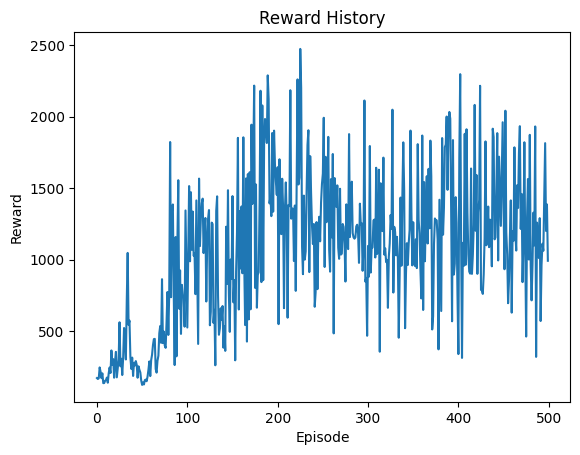

In [ ]:
import numpy as np

def train():
    env = TwolinkEnv()
    agent = PPO()
    best_reward = -float("inf")
    best_episode = 0

    rewards_history=[]

    max_episodes = 500
    max_steps = 1000

    max_timesteps = max_episodes * max_steps
    timesteps_so_far = 0

    for episode in range(max_episodes):
        state = env.reset()

        record = (episode == max_episodes - 1)

        if record:
            states_record = []
            actions_record = []

        memory = {'states':[], 'actions':[], 'log_probs':[],
                  'rewards':[], 'dones':[]}

        total_reward = 0

        for t in range(max_steps):
            action, log_prob, _ = agent.select_action(state)

            action_env = action * np.array([1.0,1.0])

            next_state, reward, done, _, = env.step(action_env)

            if record:
                states_record.append(state.copy())
                actions_record.append(action_env.copy())

            memory['states'].append(state)
            memory['actions'].append(action)
            memory['log_probs'].append(log_prob)
            memory['rewards'].append(reward)
            memory['dones'].append(done)

            state = next_state
            total_reward += reward
            timesteps_so_far += 1

            if done:
                break

        returns = []
        G = 0
        for r, d in zip(reversed(memory['rewards']), reversed(memory['dones'])):
            if d:
                G = 0
            G = r + agent.gamma * G
            returns.insert(0, G)

        memory['returns'] = returns

        cur_lrmult = max(1.0 - float(timesteps_so_far) / (max_timesteps/2), 0)
        if cur_lrmult < 1e-5:
            cur_lrmult = 1e-5

        for param_group in agent.optimizer.param_groups:
            param_group['lr'] = 3e-4 * cur_lrmult

        agent.update(memory)

        if total_reward > best_reward:
          best_reward = total_reward
          torch.save(agent.model.state_dict(),"/content/drive/MyDrive/lab_activity/2link/weights/best.pth")
          best_episode = episode

        if episode % 100 == 0:
          torch.save(agent.model.state_dict(),f"/content/drive/MyDrive/lab_activity/2link/weights/ep{episode}.pth")

        #torch.save(agent.model.state_dict(), f"/content/drive/MyDrive/lab_activity/weights/ep{episode}.pth")

        print(f"Episode {episode} | Reward {total_reward:.2f} | Step {t}")

        rewards_history.append(total_reward)

        if record:

            print(f"Best episode {best_episode}")

            plt.figure()
            plt.plot(rewards_history)
            plt.xlabel("Episode")
            plt.ylabel("Reward")
            plt.title("Reward History")
            plt.show()






train()

In [ ]:
def play_best():
    env = TwolinkEnv()

    model = ActorCritic()
    model.load_state_dict(torch.load("/content/drive/MyDrive/lab_activity/2link/weights/best.pth"))
    model.eval()

    state = env.reset()
    states_record = []
    actions_record = []

    for _ in range(1000):
        state_tensor = torch.FloatTensor(state).unsqueeze(0)
        dist, _ = model(state_tensor)

        # ←超重要：ランダムじゃなくする
        action = dist.mean.squeeze(0).detach().numpy()

        action_env = action * np.array([1.0,1.0])

        states_record.append(state.copy())
        actions_record.append(action_env.copy())

        state, _, done, _, = env.step(action_env)


        if done:
            break

    save_animation(np.array(states_record), l1,l2, np.array(actions_record))

play_best()

len(z_array): 1000


In [ ]:
def play():
    env = TwolinkEnv()
    any_episode=200

    model = ActorCritic()
    model.load_state_dict(torch.load(f"/content/drive/MyDrive/lab_activity/2link/weights/ep{any_episode}.pth"))
    model.eval()

    state = env.reset()
    states_record = []
    actions_record = []

    for _ in range(1000):
        state_tensor = torch.FloatTensor(state).unsqueeze(0)
        dist, _ = model(state_tensor)

        # ←超重要：ランダムじゃなくする
        action = dist.mean.squeeze(0).detach().numpy()

        action_env = action * np.array([1.0,1.0])

        states_record.append(state.copy())
        actions_record.append(action_env.copy())

        state, _, done, _, = env.step(action_env)


        if done:
            break

    save_animation(np.array(states_record), l1,l2, np.array(actions_record))

play()

/tmp/ipykernel_1224/128792324.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  F = float(action)


len(z_array)  191
